1. Identify the system being studied. List all relevant variables.

 > Your response: We will be  using a string and sine wave generator to produce waves at specfific frequencies that will be predicted by a mathmatical model. There is a hanging mass (M) from the string that creas a tenison (T = Mg).

2. Identify the hypothesis or model that you will test.  Provide both a verbal description of this model **and** and mathematical equation. (use $\LaTeX$)

 > Your response: Our hypothesis is that there is a linear relationship between the frequency we subject the string to and the number of nodes in the standing wave that is observed. This relationship can be modelled by the equation: $$f = (\frac{n}{2L})(\sqrt{\frac{Mg}{\mu}})$$
 Variables:  $$n = n_\text{nodes}-1$$ $$L = \text{Length of String}$$ $$M = \text{Hanging Mass}$$ $$g = 9.8 \text{ m/s}^2$$ $$\mu \text{Linear Density of the String}$$ 

3. How will you know if your experiment is successful?

 > Your response: We will know that the experiment is succesful when we observe a linear realtionship between n and f. We will then use the slope of this data to calculate the linear density of the string ($\mu$) to show that the model works. $$m = \sqrt{\frac{Mg}{\mu}} \frac{1}{2L}$$ so $$\mu = \frac{Mg}{(2Lm)^2}$$
 
4. Plan your analysis.

 > Your response: First, we will collect a number of frequencies at which we observe standing waves with specific ammounts of nodes. We will use the f and n values to construct a polot of f as a function of n that is expected to have a linear curve. Using the slop of that curve, we will caluculate the linear density of the string we are using, and then confirm that value by measuring the linear density of the string.

5. Choose reasonable ranges for the pertinent variables in your experiment.

 > Your response: The variables we will be mannipulating are f and n. We will change the frequency until certain values of n ($n_{nodes} - 1$) are observed and then record our results. The range of n that we will use are n = 2-10.

6. Plan the experimental procedure.

 > Your response: 1.) Set up the system by conecting a string to the sine wave generator and creating tension in it by hanging mass. 2.) Start at 0 frequency and slowly increase frequecny using the sine wave generator until a standing wave is observed at various n values ($n = n_{nodes} - 1$). 3.) Record the frequencies at which the n values are observed and then contruct plot of f as a function of n. 4.) Proceed with analyisis of the plot and use the slope to predict the linear density of the string. 5.) Measure the linear dentisy of the string and compare with predicted result. 

7. Carry out the experiment and report your results. Include all data collected, plots constructed and give evidence for or against your hypothesis.  Data should be placed in a table of some kind.  You can either use a markdown table in a text cell or a Pandas dataframe (see activity I from lab 2 for a refresher) to display the data.

 > Your response:

,n (nodes-1),F (Hz)
1,1.0,9.1
2,2.0,18.4
3,3.0,26.9
4,4.0,38.1
5,5.0,46.7
6,6.0,55.4
7,7.0,64.8
8,8.0,74.2
9,9.0,83.2
10,10.0,92.3


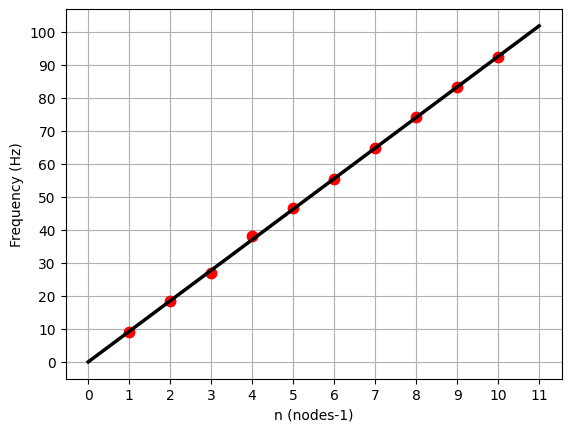

In [2]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt
from numpy import polyfit,linspace
from pandas import DataFrame

n = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
f = np.array([9.1, 18.4, 26.9, 38.1, 46.7, 55.4, 64.8, 74.2, 83.2, 92.3])

g = 9.8
M = .250
δM = .001
L = 1.782
δL = .003


params = polyfit(n, f, 1, cov = True)
ndense = linspace(0, 11, 200)
fdense = params[0][0] * ndense + params[0][1]

plt.plot(n, f, 'r.', ms = 15)
plt.plot(ndense, fdense, 'k', lw = 2.5) 
plt.xlabel("n (nodes-1)")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]);
plt.yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]);

df = DataFrame(np.transpose([n, f]), columns = ["n (nodes-1)", "F (Hz)"],index = list(range(1,11)))
display(df)

We have now verified that the realtionship between n and f is linear. We can now use the slope of out best-fit line to predict the linear density of our string and therefore support the model we are testing.

In [3]:
import numpy as np
m = params[0][0]
δm = np.sqrt(params[1][0][0])

slope, mass, length, gravity = sp.symbols("slope mass length gravity")
μ = (mass*gravity)/(2*slope*length)**2
dμdm = sp.diff(μ, slope)
dμdM = sp.diff(μ, mass)
dμdL = sp.diff(μ, length)

values = {slope:m, mass:M, length:L, gravity:g}

μ = (M*g)/(2*L*m)**2
δμ = sp.sqrt((dμdm.subs(values)*δm)**2+(dμdM.subs(values)*δM)**2+(dμdL.subs(values)*δL)**2)

M_string = .01393
δM_string = .00002
L_string = 3.65
δL_string = .001

μ_measured = M_string/L_string
δμ_measured = sp.sqrt((δM_string/M_string)**2+(δL_string/L_string)**2)


print(f"The predicted value for linear density is {μ} +- {δμ}.")
print(f"the measured value for the linear density is {μ_measured} +- {δμ_measured}.")

The predicted value for linear density is 0.002249999516617083 +- 0.0000306838147626065.
the measured value for the linear density is 0.0038164383561643837 +- 0.00146165644557693.


Conclusion
----
The results of our experiment are mixed. We do have a strong linear trend in our data, indicating the expectre relationship. However, we were unable to accuratly estimate the linear deinsity of the string. We beleive that this is do to a couple confounding variables. 

Most notably, the elasticity of the string. When the mass was hanging from the string to create tension, the string was simultaneously being stretched. This strethced length was then measured and used to predict linear density. Then, when we released the weight and measure d the length of the string to measure desnity physically, the string was not stretched at all. This inconsistency would create a notibale difference in the predicted vs. measured values. If we were to repeat the experiment, paying closer attention to the length and accurately measuring that would improve results.  